In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import qutip as qt
import scipy.optimize as opt
import os 
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from joblib import Parallel, delayed
H = np.array([[1],[0]])
V = np.array([[0],[1]])
D = 1/np.sqrt(2)*(H+V)
A = 1/np.sqrt(2)*(H-V)
R = 1/np.sqrt(2)*(H+1j*V)
L = 1/np.sqrt(2)*(H-1j*V)
basismap = {
    'H': H,
    'V': V,
    'D': D,
    'A': A,
    'R': R,
    'L': L
}

I = np.array([[1,0],[0,1]])
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])
pauli = [I,X,Y,Z]

In [2]:
def plot_matrix_heatmap(matrix, title=""):
    """Plot real and imaginary parts of a matrix as side-by-side heatmaps."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    n = matrix.shape[0]
    ticks = np.arange(n)
    
    im1 = ax1.imshow(matrix.real, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    ax1.set_title(f"Re({title})" if title else "Real Part")
    ax1.set_xticks(ticks)
    ax1.set_yticks(ticks)
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    im2 = ax2.imshow(matrix.imag, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    ax2.set_title(f"Im({title})" if title else "Imaginary Part")
    ax2.set_xticks(ticks)
    ax2.set_yticks(ticks)
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    return fig

# State and Process Tomography: Post-Lab
Prepared by Jeremie Corkery
March 6th, 2026

# Question 1: Experimental Set-Up and Theory
In this topic, we explore process and state tomography which is the reconstrucion of a density or process matrix based on a set of tomographically complete measurements. A tomographically complete set is defined as a set of measurement operators that spans the operator space of the desired density matrix $\rho$. For single qubit state tomography requires 4 measurements, and in our case we measure in the pauli basis measuring the states $b =\{ H, V, D, R \}$. For process tomography, we are attempting to reconstruct the process matrix $\chi$, which effectively decomposes a quantum channel into the pauli-basis. To perform process tomography on a single qubit requires a tomographically complete set over $\chi$, which we can find by taking the tensor product between a tomographically complete set of inputs and tomographically complete set of outputs, this we require 16 measurements. 

To perform these tomography experiments, we have use the following equipment to create a basic prepare, process, measure experimental set-up:
- 804nm thorlabs laser diode
- 2 polarizing beamsplitters
- 2 thorlabs quarter wave-plates
- 2 thorlabs half wave-plates
- 1 thorlabs power meter

Processes:
- 1 "good" half wave-plate
- 1 "bad" half wave-plate
- 2 microscope slides to act as a partial polarizer
- 1 calcite beam displacer

Set-up as follows: 
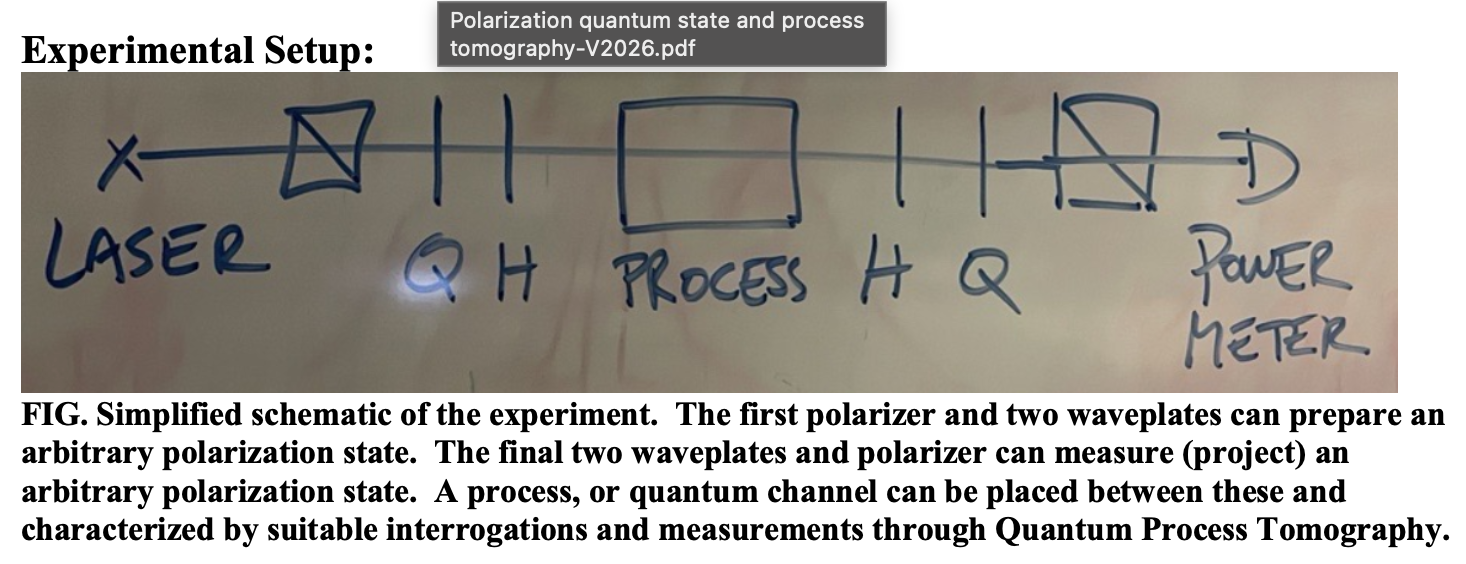

If we trace the path of the eam the set-up works as follows. We shine the laser through the first PBS, this will transmit H and reflect V and we discard/block the reflected path with a beam block. The transmitted H polarixed light goes through the quarter and half wave-plate (this is our state preparation stage). We can change the angle of the fast axis on these wave-plates to prepare an arbitrary state. During experiment #1 we find the zeros of these wave-plates to determine what angles we need to use to prepare our HVDR states. In other words this stage takes in arbitrary polarized light, filters it to be H only light, and then maps H to an arbitrary state. 

After we prepare our state, it passes through the processing stage which implements a quantum channel. We explore various type of channels:

Unitary and trace preserving:
- Identity channel (no optical element)
- Hadamard channel (HWP set to it's 22.5 degree setting)
- Faulty HWP channel (a defective HWP which doesn't have the correct retardance)

Trace preserving non-unitary channel: 
- calcite beam displacer

Non-trace preserving channel: 
- partial polarizer (tilted microscope slide pair)

Lastly, the final portion of our experimental set-up is our measurement stage where we have a HWP followed by a QWP followed by a PBS and a power meter to measure the resulting intensity. The waveplates work by mapping an arbitrary state to H, which then goes through the PBS which only transmits H through to the power meter. This allows us to effectively measure the arbitrary state we mapped to H, since only this state's contribution will be passed to the power meter. 

# Set-Up Callibration/Characterization


As mentioned we must callibrate and characterize our set-up so that we know the parameters for our waveplate we need to use to prepare and measure our basis states so that in following experiments we can take measurements over a tomographically complete set of states. We do this with the following procedure. 


Our first step is to find the zero of our quarter waveplates. To do this we start with only the PBS's and our first QWP. We adjust the angle of the QWP and find the angle that gives us the maximum power. Each QWP has 4 zeros so we test each one to find which will give us the highest measured power. 

QWP1 characterization:

| Power (mW) | Angle (deg) |
| --- | --- |
| 2.321 | -4 |
| 2.327 | 270 |
| 2.317 | 180 |
| 2.328 | 90 |

so our first QWP's zero is 90deg

We zero QWP1 and repeat this procedure for QWP2

QWP2 characterization:

| Power (mW) | Angle (deg) |
| --- | --- |
| 2.319 | 268 |
| 2.319 | 178 |
| 2.315 | 88 |
| 2.315 | -4 |

So our 2nd QWP's zero is 268deg. 

We repeat this process by adding HWP1 and HWP2 to characterize them

HWP1 characterization:

| Power (mW) | Angle (deg) |
| --- | --- |
| 2.265 | -2 |
| 2.297 | 88 |
| 2.278 | 178 |
| 2.240 | 268 |

HWP2 characterization:

| Power (mW) | Angle (deg) |
| --- | --- |
| 2.283 | 268 |
| 2.288 | -2 |
| 2.288 | 178 |
| 2.285 | 178 |

so HWP1 and HWP2 have their zero we will use at 88deg. 

Using this then, we can find the angles we need to use to prepare and measure each possible state. 

The reported uncertainty for all our our measurements here is 0.0005mW and +-1 degrees

Hence we use the following settings to prepare and measure each state
**Preparing States:**

| State | QWP (deg) | HWP (deg) |
| --- | --- | --- |
| H | 90 | 88 |
| V | 90 | 133 |
| D | 90 | 110.5 |
 R | 45 | 88 |

**Measuring States:**

| State | HWP (deg) | QWP (deg) |
| --- | --- | --- |
| H | 88 | 268 |
| V | 133 | 268 |
| D | 110.5 | 268 |
| R | 88 | 313 |

# Question 2: Quantum State Tomography of Single Photon Pure State

In this question we analyze our results to experiment #2. Experiment #2 had us perform quantum state tomography for single photon pure state for the H and R states. In this experiment our process stage of our experimental set-up is the identity channel. We measure the states H,V,D, and R. For part b) of this question we also measured A and L to compare if our predicted measurements based on our reconstruction allign with what we measured exprimentally. 

The goal of state tomography is to reconstruct the density matrix rho, which as we know has trace=1 and is positive semi-definite and hermitian. To do this we take a set of tomographically complete measuremnts (in our case since we only have 1 qubit this is 4 measurements H,V,D and R). Using these measurements, we can perform maximum likelihood estimation (MLE) by minimizing the following loss function: 

$$\mathcal{L} = \frac{\sum_\nu(a*\langle\phi_\nu|\rho|\phi_n\rangle-P_\nu)}{2\sigma_{P_\nu}^2}$$

where $\phi_nu$ is the state we are measuring, $\P_nu$ is the power we measure and our sigma is the uncertainty in our power measurement. However, to ensure our MLE process gives us a physical result (i.e. that our reconstructed rho has the appropriate properties for a density matrix), we must find a parametrization that enforces this constraints. One such parametrization is the so called Choleski decomposition of rho defined as followed:

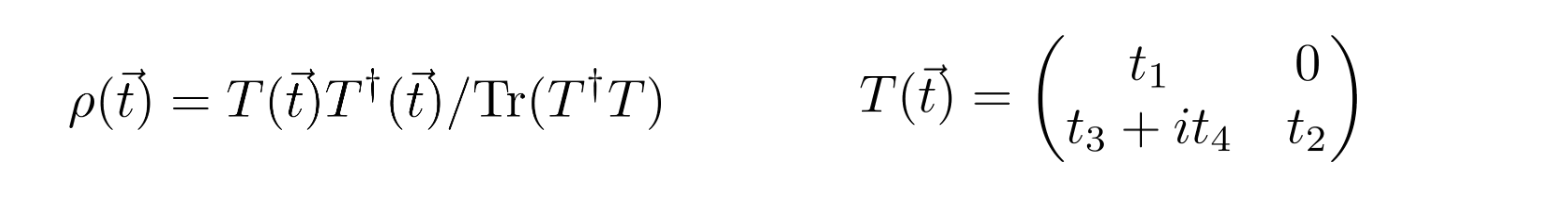

This ensures we get a physical density matrix at the end of our MLE procedure. 

Once we reconstruct rho, we can find the fidelity ($Tr(\sqrt{\sqrt{\rho}\sigma\sqrt{\rho}})^2$) and purity ($Tr(\rho^2$)) of our input state. We find the mean and uncertainty of these values by performing monte-carlo uncertainty estimation which adds noise to our measurement according to our known noise process (in this case we assume the error in our power meter is gaussian). We also apply this same process to find the mean value for rho. 

In [3]:
def read_measurements(filename):
    '''
    Helper function to load a file of measurment with corresponding basis, will generate a list with appropriate basis vectors (which can be useful for overcomplete bases)
    '''
    #get path
    path = os.path.join(os.getcwd(),filename)
    #load file
    df = pd.read_csv(path, delimiter = '\\s+')
    #map basis letter/name to vector
    states = np.array(df['state'][0::])
    states = [basismap[b] for b in states]
    #make sure measurements are numerical
    measurements = np.array(df['measurements'][0::].astype('float'))
    uncertainties = np.array(df['uncertainty'][0::].astype('float'))
    return (states, measurements, uncertainties)


def rho_cholesky(t):
    '''
    returns rho from cholesky decomposition
    '''
    #Parametrized cholesky matrix
    T = np.array([[t[0],0],[t[1]+1j*t[2],t[3]]])
    #constructed valid density matrix (positive and trace 1)
    return (T.conj().T @ T)/(np.trace(T.conj().T @ T))

"""def count_objective(t, counts, N, projectors):
    '''
    loss function for photon count data (assumes poisonian error model)
    t: optimization parameters, list
    counts: measurements
    basis: list of basis states, should match 
    N: photon count rate
    projectors: list of projectors for measurements
    '''
    #initialize rho
    rho = rho_cholesky(t)
    #initialize loss to 0    
    loss = 0
    for i in range(len(counts)):
        #expected counts according to born's
        predicted = N*np.real(np.trace(projectors[i] @ rho))
        
        #ith term contributing to loss
        loss += (predicted-counts[i])**2/(2*predicted)
    
        
    return loss"""

def power_objective(t, measurements, uncertainties, projectors):
    '''
    loss function for power measurements

    t: fit parameter
    measurements: list of measurements from power meter
    uncertainties: list of uncertainties in powermeter readings (uncertainty or variance/sd?)
    a: constant with units of power
    projectors: projectors for associated measurement
    '''
    #initialize rho and loss
    rho = rho_cholesky(t)
    loss = 0

    for i in range(len(measurements)):
        #born rule
        born = np.real(np.trace(projectors[i]@rho))
        #ith measurements contribution to loss
        loss += (t[4]*born-measurements[i])**2/(2*uncertainties[i]**2)

    return loss

def MLE_tomo(f, states, args, verbose = False):
    '''
    function to do MLE state tomography and reconstruct the appropriate density matrix

    f: loss/objective function
    t_init: inital parameter guess
    basis: list of measured states to construct projectors
    args: tuple with appropriate kwargs needed for loss/objective function
    '''
    #compute projectors (builds ordered list of projectors based on performed measurements)
    projectors = [np.outer(s,s.conj()) for s in states]
    #convert args to a tuple, add projectors to args
    args.append(projectors)
    args = tuple(args)

    #get best fit parameters
    bounds = [(-1,1),(-1,1),(-1,1),(-1,1),(0,3)]
    params = opt.dual_annealing(f, bounds = bounds, args = args).x
    #compute rho based on fit parameters
    rho = rho_cholesky(params[0:4])
    N = params[-1]
    if verbose:
        with np.printoptions(3, suppress=False):
            print(f'MLE Reconstructed Density Matrix RHO: \n {rho} \n')

    return rho, N

def fidelity(rho: np.ndarray, sigma: qt.Qobj):
    '''
    computes fidelity between two density matrices
    '''
    rho = qt.Qobj(rho)
    return qt.fidelity(rho, sigma)


def monte_carlo(f, sigma, states, args, num_samples, expect = False, n_jobs=-1):
    '''
    function to compute uncertainty in fidelity via monte carlo sampling

    f: loss/objective function
    rho: reconstructed density matrix
    states: list of measured states to construct projectors
    args: tuple with appropriate kwargs needed for loss/objective function
    num_samples: number of monte carlo samples to take
    n_jobs: number of parallel jobs (-1 uses all cores)
    '''
    
    def run_single_sample(seed):
        """Helper function to run a single Monte Carlo sample"""
        np.random.seed(seed)
        #add noise to measurements
        noisy_measurements = args[0] + np.random.normal(0, args[1], size = len(args[0]))
        #update args with noisy measurements
        new_args = [noisy_measurements, *args[1:]]
        #get new rho based on noisy measurements
        new_rho, N = MLE_tomo(f, states, new_args)
        return new_rho, N
    
    # Run samples in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(run_single_sample)(i) for i in range(num_samples)
    )
    
    # Unpack results
    rhos = [r[0] for r in results]
    Ns = [r[1] for r in results]

    fidelities = [fidelity(rho, sigma) for rho in rhos]
    purities = [np.real(np.trace(rho @ rho)) for rho in rhos]
    if expect:
        rho_A = np.outer(A,A.conj())
        rho_L = np.outer(L,L.conj())
        As = [np.real(np.trace(rho @ rho_A)) for rho in rhos]
        Ls = [np.real(np.trace(rho @ rho_L)) for rho in rhos]
    #compute standard deviation of fidelities as uncertainty
    mean_f = np.mean(fidelities)
    mean_p = np.mean(purities)
    mean_N = np.mean(Ns)
    mean_rho = np.mean(rhos, axis=0)
    uncertainty_f = np.std(fidelities)
    uncertainty_p = np.std(purities)
    uncertainty_N = np.std(Ns)
    if expect:
        mean_A = np.mean(As)
        mean_L = np.mean(Ls)
        uncertainty_A = np.std(As)
        uncertainty_L = np.std(Ls)
        return mean_f,mean_p,mean_N,mean_rho,uncertainty_f, uncertainty_p, uncertainty_N, mean_A, mean_L, uncertainty_A, uncertainty_L
    return mean_f,mean_p,mean_N,mean_rho,uncertainty_f, uncertainty_p, uncertainty_N
    

    


    

# Q2a)
Bellow we present the results of our state tomography for experiment 2 when preparing the H state using the appropriate wave plate settings we describe in question #1. We expect this to give us the following density matrix: 

$$\rho = |H\rangle \langle H| = \begin{pmatrix} 1 & 0 \\ 0 & 0\end{pmatrix}$$

which we use this to calculate the fidelity of our reconstruction. 

reconstructed rho: 
 [[0.99746124+0.j         0.02149918+0.02059014j]
 [0.02149918-0.02059014j 0.00253876+0.j        ]] 

total input power: 2.281809416075802 +- 0.0038466100991298062 

fidelity rho and H: 0.9987 +- 0.0008350232514878677 
 
purity of rho: 0.9967 +- 0.0033148745968343335 



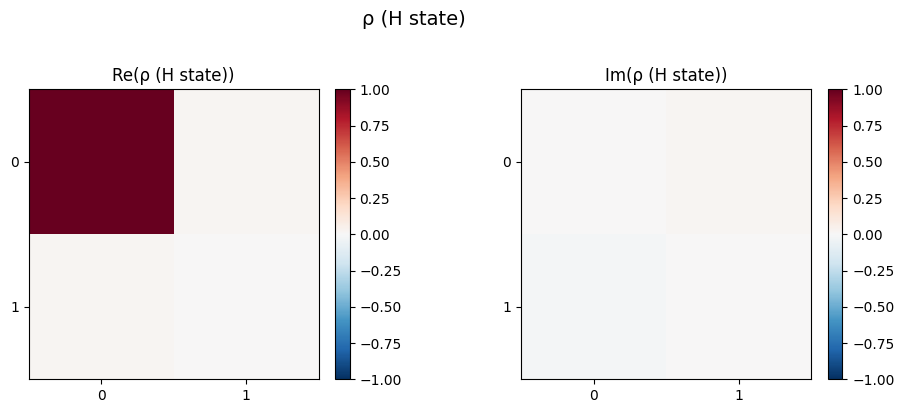

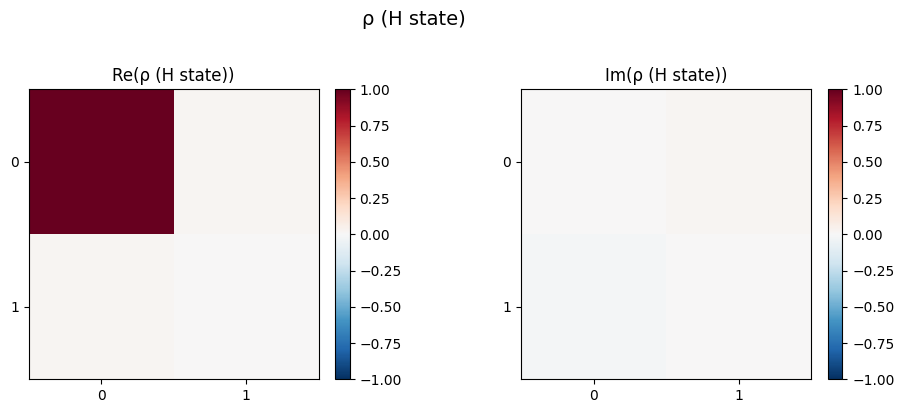

In [4]:
data = read_measurements('Hstatetomot.txt')
states = data[0]
measurements = data[1]
uncertainties = data[2]
    
sigmaH = qt.ket2dm(qt.Qobj(H))
mean_fidelity, mean_purity, mean_N, mean_rho, uncertainty_f, uncertainty_p, uncertainty_N = monte_carlo(power_objective, sigmaH, states, args = [measurements, uncertainties], num_samples = 100)
print(f'reconstructed rho: \n {mean_rho} \n')
print(f'total input power: {mean_N} +- {uncertainty_N} \n')
print(f'fidelity rho and H: {mean_fidelity:.4f} +- {uncertainty_f} \n ')
print(f'purity of rho: {mean_purity:.4f} +- {uncertainty_p} \n')
plot_matrix_heatmap(mean_rho, title='ρ (H state)')



As we can see, we get a reconstructed matrix that is very close to what we would expect theoretically with a fidelity $ F(\rho) = 99.87 \pm 0.08 \% $ and a purity $ P(\rho) = 99.67 \pm 0.3\%$. We also get a reconstructed input power of $2.282\pm0.003$ mW which is consistent with our measurements. 

# Q2b)
Here we present the results of our process tomography experiment for preparing the R state. We expect a theoretical density matrix $$\rho = |R\rangle\langle R| = 0.5\begin{pmatrix}1 & -i \\ i & 1\end{pmatrix}$$

total input power: 2.3160163349458514 +- 0.0006989491553845729 

reconstructed rho: 
 [[ 0.48834362+0.j         -0.00347485-0.48268671j]
 [-0.00347485+0.48268671j  0.51165638+0.j        ]] 

fidelity rho and R state: 0.9913 +- 0.00019090613870906086
purity of rho: 0.9663 +- 0.0007296481975536086

Born A: 0.5034748470675209 +- 0.00023211701745881182

Born L: 0.017313294206875295 +- 0.0003784910832623808 

expected A: 1.1660559700427426 +- 0.0006425227761696748 

expected L: 0.04009787219484656 +- 0.0008766750538027877 



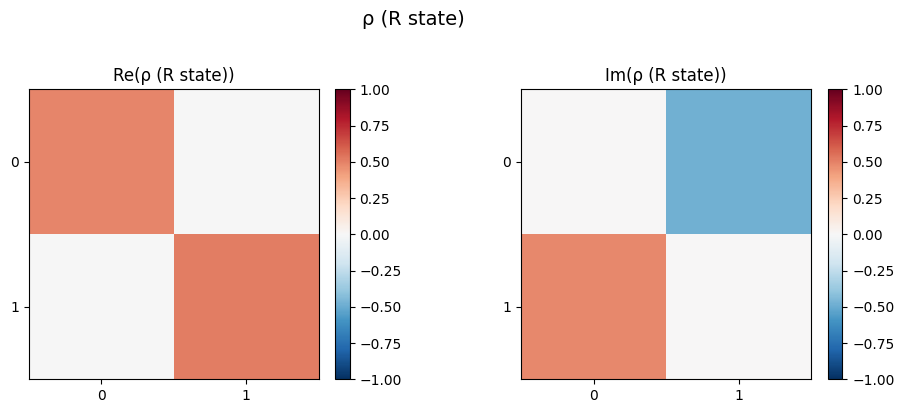

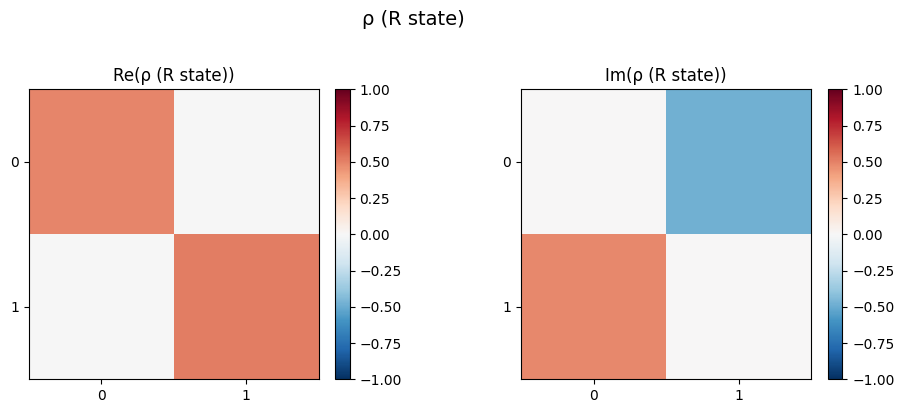

In [561]:
data = read_measurements('Rstatetomo.txt')
states = data[0]
measurements = data[1]
uncertainties = data[2]
sigmaR = qt.ket2dm(qt.Qobj(R))

mean_fidelity, mean_purity, mean_N, mean_rho, uncertainty_f, uncertainty_p, uncertainty_N, mean_A, mean_L, uncertainty_A, uncertainty_L = monte_carlo(power_objective, sigmaR, states, args = [measurements, uncertainties], num_samples = 100, expect = True)
print(f'total input power: {mean_N} +- {uncertainty_N} \n')
print(f'reconstructed rho: \n {mean_rho} \n')
print(f'fidelity rho and R state: {mean_fidelity:.4f} +- {uncertainty_f}')
print(f'purity of rho: {mean_purity:.4f} +- {uncertainty_p}\n')
print(f'Born A: {mean_A} +- {uncertainty_A}\n')
print(f'Born L: {mean_L} +- {uncertainty_L} \n')
#use error propagation to compute uncertainty in expected A and L
expected_A = mean_A*mean_N
expected_L = mean_L*mean_N
uncertainty_expected_A = expected_A*np.sqrt((uncertainty_A/mean_A)**2 + (uncertainty_N/mean_N)**2)
uncertainty_expected_L = expected_L*np.sqrt((uncertainty_L/mean_L)**2 + (uncertainty_N/mean_N)**2)
print(f'expected A: {expected_A} +- {uncertainty_expected_A} \n')
print(f'expected L: {expected_L} +- {uncertainty_expected_L} \n')
plot_matrix_heatmap(mean_rho, title='ρ (R state)')




Here we see we get a total reconstructed power of $ P = 2.316 \pm 0.0007$ mW, a fidelity of $ F(\rho, \rho_R) = 99.13 \pm 0.01\% $ and a purity of $ P(\rho) = 96.63 \pm 0.07\% $. 

We also find that we get a reconstructed value for the power we expect when we measure A of $1.166\pm0.0007$ mW and for L of $0.040 \pm 0.0008$ which agrees reasonably well with what we expect to measure for these (i.e. about 1/2 of our total power for A and near 0 for L). We measured in the lab 1.087mW for A and 2.85µW for L. Deviations can likely be attributed to waveplate setting's not exactly matching the appropriate settings for L and A. 

# Q3
Here we present the results of experiment 3 where we prepare a mixed state by preparing R in our preparation stage and adding a beam displacer to our process stage. The beam displacer couples our state to a spatial degree of freedom (effectively entangling the spatial and polarization degree of freedom). By measuring both paths simultaneously we trace over the spatial degree of fredom and we are left with a maximally mixed state. What we expect for this density matrix is $$\rho = \begin{pmatrix} 0.5 & 0 \\ 0 & 0.5 \end{pmatrix}$$

 Here, we expect our purity to be 1/2 as we have a maximally mixed state (which by definition is the lowest purity state we can get for a given system).

total input power: 2.2310163382982005 +- 0.000698953638325751 

reconstructed rho: 
 [[ 0.48453783+0.j        -0.00114199-0.0060108j]
 [-0.00114199+0.0060108j  0.51546217+0.j       ]] 

fidelity rho and maximally mixed state: 0.99986 +- 2.8779270033412376e-06
purity of rho: 0.5006 +- 1.1503734486556517e-05



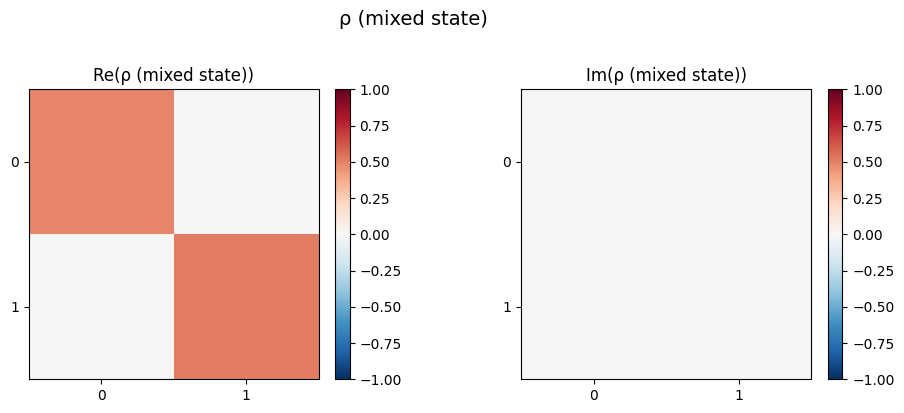

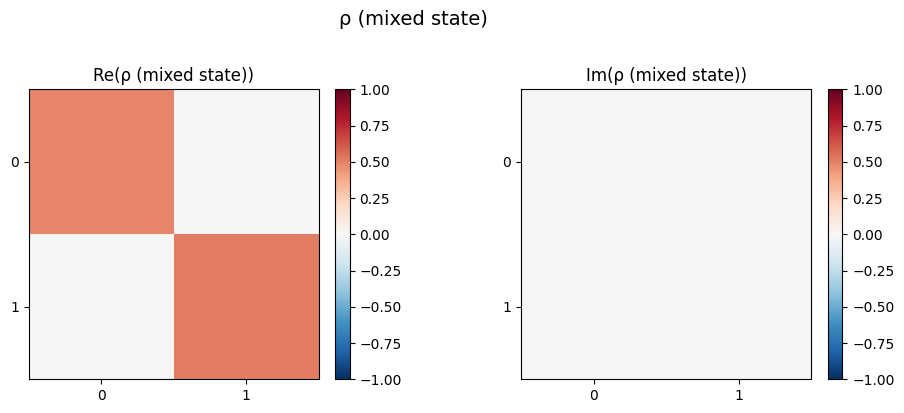

In [562]:
data = read_measurements('mixedtomo.txt')
states = data[0]
measurements = data[1]
uncertainties = data[2]
sigmaM = qt.Qobj([[0.5,0],[0,0.5]])
mean_fidelity, mean_purity, mean_N, mean_rho, uncertainty_f, uncertainty_p, uncertainty_N = monte_carlo(power_objective, sigmaM, states, args = [measurements, uncertainties], num_samples = 100)
print(f'total input power: {mean_N} +- {uncertainty_N} \n')
print(f'reconstructed rho: \n {mean_rho} \n')
print(f'fidelity rho and maximally mixed state: {mean_fidelity:.5f} +- {uncertainty_f}')
print(f'purity of rho: {mean_purity:.4f} +- {uncertainty_p}\n')
plot_matrix_heatmap(mean_rho, title='ρ (mixed state)')



Here we can see that we get a reconstructed ttoal power of $2.2309 \pm 0.0007$ mW, a fidelity of $ F(\rho, \rho_R) = 0.99986 \pm 0.000003 \% $ and a purity of $P(\rho) = 0.5006\pm0.00001 \% $ The main difference comes between this set of mesurement with the calcite beam displacer and simply preparing R is that in one case we have R, while in the other we trace out part of our wavefunction and end up with a maximally mixed state. For the maximally mixed state we expect all our measurement to be approximately 1/2 of our total input power which is exactly what we observed while in the pure state we expect the R measurement to be equal to our input power (since we prepare R, do nothing, and measure R) within a margin of error. We also expect the maxmimally mixed state to give us a density matrix with a purity of 1/2 which is exactly what we get while the R measurement without the calcite beam displacer should give us a purity close to 1 which again is exactly what our results show. 

# Q4

In the following questions we now turn to process tomography which is very similar to state tomography, but here we instead try to reconstruct a physical process/quantum channel rather than a state. As such, to have a tomographically complete set for 1 qubit process tomography we require measurement over a set of tomographically complete input and output pairs (there we have 16 measurements total since our input set has 4 states and our output state has 4 state, 4x4=16). 

Typically we describe quantum channels using the Krauss form, however this is poorly suited to being parametrized as a channel can (in theory) have as many Krauss operators as needed. What we can do instead, is describe our channel by decomposing our krauss operators into the pauli basis $E_i = \sum_m a_{im} \sigma_m$ so our channel becomes

$$\rho' = \sum_i E_i\rho E_i^\dag = \sum_{mn}\sum{_i}a_{im}a_{in}^*\sigma_m \rho \sigma_n = \sum_mn = \chi_{mn}\sigma_m \rho \sigma_n$$

Where we introduce the chi matrix which completely describes our process/quantum channel. However, once again we need to enfoce some specific properties for chi to give us physical results. 

For questions 4 and 5 we specifically concern ourselves with trace preserving channels and as such we care about enforcing trace preservation, hermicity, positive semi definite and trace 1 for chi to be physical. Therefore once again here we can use the Cholesky decomposition, but instead of a 2x2 matrix with 4 parameters we have a 4x4 matrix with 16 parameters. 

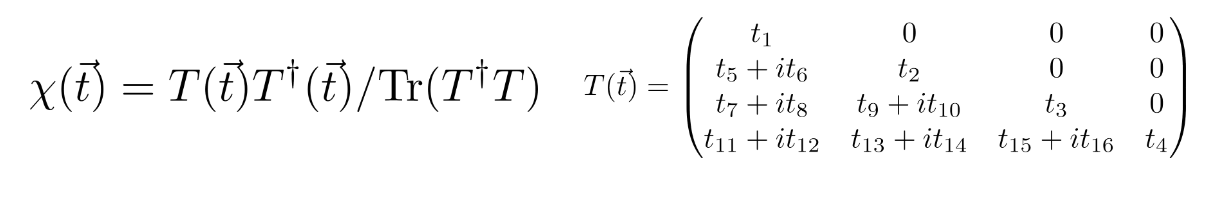

Our basic loss function to estimate chi is therefor

$$\mathcal{L} = \sum_{ij}\frac{(n_{ij}-N\sum_{mn}\chi_{mn} \langle m_j|\sigma_m |\phi_i\rangle \langle \phi_i |\sigma_n|m_j\rangle)^2 )}{n_{ij}}$$

Now another constraint we need to enforce for our quantum channel is that $\sum_{nm}\chi_{mn}\sigma_n\sigma_m = I$. As such , we add a regularizer to our loss function which will enforce this constraint and our loss function then becomes

$$\mathcal{L} = \sum_{ij}\frac{(n_{ij}-N\sum_{mn}\chi_{mn} \langle m_j|\sigma_m |\phi_i\rangle \langle \phi_i |\sigma_n|m_j\rangle)^2 )}{n_{ij}} + \lambda \sum_k [Tr(\sigma_k (\sum_{nm} \chi_mn \sigma_n \sigma_m) - Tr(\sigma_k)]^2$$

We also once again use monte carlo mean and uncertainty estimation for our reported values and uncertainties. 

In [5]:
def read_process(filename, basis = ['H','V','D','R']):
    df = pd.read_csv(os.path.join(os.getcwd(),filename), delimiter='\\s+')
    inputs = df['in']
    outputs = df['out']
    measurements = np.array(df.pivot_table(index = ['in'], columns = ['out'], values = 'measure', aggfunc='mean').reindex(index=basis,columns=basis))
    uncertainties = np.array(df.pivot_table(index = ['in'], columns = ['out'], values = 'uncertainty', aggfunc='mean').reindex(index=basis,columns=basis))
    return (inputs,outputs, measurements, uncertainties)

def process_fidelity(chi, ideal_chi, TP):
    #compute process fidelity between reconstructed chi and ideal chi (sigma)
    sqrt_chi = qt.Qobj(chi).sqrtm()
    ideal_chi = qt.Qobj(ideal_chi)
    if TP:
        return np.real((sqrt_chi @ ideal_chi @ sqrt_chi).sqrtm().tr())**2
    else:
        return np.real((sqrt_chi @ ideal_chi @ sqrt_chi).sqrtm().tr())**2/np.real(qt.Qobj(chi).tr()*ideal_chi.tr())
    
def chi_choleski(t):
    T = np.array([[t[0],0,0,0],[t[4]+1j*t[5],t[1],0,0],[t[6]+1j*t[7],t[8]+1j*t[9],t[2],0],[t[10]+1j*t[11],t[12]+1j*t[13],t[14]+1j*t[15],t[3]]])
    chi = (T.conj().T@T)/(np.trace(T.conj().T@T))
    return chi

def chi_choleski_unconstrained(t):
    T = np.array([[t[0],0,0,0],[t[4]+1j*t[5],t[1],0,0],[t[6]+1j*t[7],t[8]+1j*t[9],t[2],0],[t[10]+1j*t[11],t[12]+1j*t[13],t[14]+1j*t[15],t[3]]])
    chi = (T.conj().T@T)
    return chi


def pauli_sum(chi, i, j, basis):
    sum = 0
    for m in range(len(pauli)):
        for n in range(len(pauli)):
            sum += (chi[m,n]*(basismap[basis[j]].conj().T@pauli[m]@basismap[basis[i]])*(basismap[basis[i]].conj().T@pauli[n]@basismap[basis[j]]))[0,0]
    return sum

def reg_sum(chi):
    sum = 0
    for n in range(len(pauli)):
        for m in range(len(pauli)):
            sum+=chi[m,n]*(pauli[n]@pauli[m])
    return sum        

def trace_preserving(t, data, l, basis = ['H','V','D','R']):
    measurements = data[2]
    uncertainties = data[3]
    chi = chi_choleski(t)
    loss = 0
    #main loss term
    for i in range(len(basis)):
        for j in range(len(basis)):
            loss += (measurements[i,j]-t[16]*pauli_sum(chi, i,j,basis))**2/(uncertainties[i,j]+1e-6)

    #regularizer
    reg = 0
    for k in range(len(pauli)):
        reg += (np.trace(pauli[k]@reg_sum(chi))-np.trace(pauli[k]))**2

    return np.real(loss+l*reg)

def MLE_process(f, filename, l, basis = ['H','V','D','R'], TP = True):
    data = read_process(filename)
    args = (data, l, basis)

    if TP:
        bounds = [(-1,1)]*16 + [(0,3)]
    else:
        bounds = [(-1,1)]*16 + [(0.5,3)] + [(0,1)] + [(-1,1)]*8
    params = opt.dual_annealing(f, bounds = bounds, args = args).x
    if TP:
        chi = chi_choleski(params)
        N = params[-1]
    else:
        chi = chi_choleski_unconstrained(params)
        N = params[16]

    with np.printoptions(3, suppress=True):
        print(f'Total Power: {N}')
        print(f'Reconstructed Chi Matrix: \n {chi}')

    return chi

def monte_carlo_process(f, filename, ideal_chi, l, num_samples, basis = ['H','V','D','R'], TP = True, n_jobs=-1):
    data = read_process(filename)
    measurements = data[2]
    uncertainties = data[3]
    
    def run_single_process_sample(seed):
        """Helper function to run a single Monte Carlo sample for process tomography"""
        np.random.seed(seed)
        noisy_measurements = measurements + np.random.normal(0, uncertainties)
        new_data = (data[0], data[1], noisy_measurements, uncertainties)
        args = (new_data, l, basis)
        if TP:
            bounds = [(-1,1)]*16 + [(0,3)]
        else:
            bounds = [(-1,1)]*16 + [(0.5,3)] + [(0,1)]+ [(-1,1)]*8
        params = opt.dual_annealing(f, bounds = bounds, args = args).x
        if TP:
            chi = chi_choleski(params)
        else:
            chi = chi_choleski_unconstrained(params)
        if TP:
            N = params[-1]
        else:
            N = params[16]
        return chi, N
    
    # Run samples in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(run_single_process_sample)(i) for i in range(num_samples)
    )
    
    # Unpack results
    chis = [r[0] for r in results]
    Ns = [r[1] for r in results]
    fidelities = [process_fidelity(chi, ideal_chi, TP) for chi in chis]

    #filter chi's that givef fidelity under 0.9
    chis = [chi for chi, fidelity in zip(chis, fidelities) if fidelity > 0.9]
    fidelities = [fidelity for fidelity in fidelities if fidelity > 0.9]

    mean_chi = np.mean(chis, axis=0)
    mean_N = np.mean(Ns)
    uncertainty_N = np.std(Ns)
    mean_F = np.mean(fidelities)

    uncertainty_F = np.std(fidelities)
    uncertainty_chi = np.std(chis, axis=0)



    with np.printoptions(3, suppress=True):    
        print(f'Total Power: {mean_N} +- {uncertainty_N}')
        print(f'Reconstructed Chi Matrix: \n {mean_chi}')
        print(f'Process Fidelity: {mean_F} +- {uncertainty_F}')
    return mean_chi, mean_N, uncertainty_N, mean_F, uncertainty_F, uncertainty_chi

# Q4a)
In this experiment, we present the results of process tomography on the identity channel. We expect chi to have the form $$\chi = \begin{pmatrix} 1&0&0&0 \\ 0&0&0&0\\ 0&0&0&0\\ 0&0&0&0\end{pmatrix}$$

We use this matrix to calculate the fidelity of our reconstruction/process. Physically we have no optical element in our processing stage.

Total Power: 2.275546527194419 +- 0.0034502751194753004
Reconstructed Chi Matrix: 
 [[ 0.992+0.j     0.004+0.008j -0.006-0.016j  0.001-0.019j]
 [ 0.004-0.008j  0.002+0.j     0.001+0.001j -0.001-0.002j]
 [-0.006+0.016j  0.001-0.001j  0.003+0.j    -0.001-0.001j]
 [ 0.001+0.019j -0.001+0.002j -0.001+0.001j  0.003+0.j   ]]
Process Fidelity: 0.9921383057822115 +- 0.002171146567940099


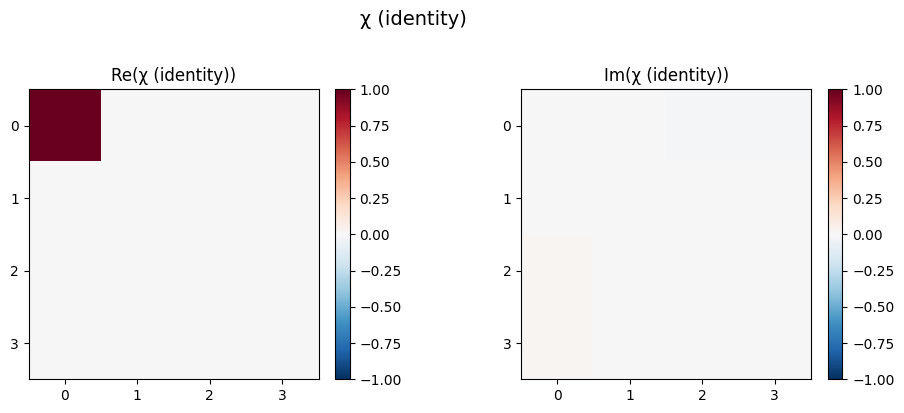

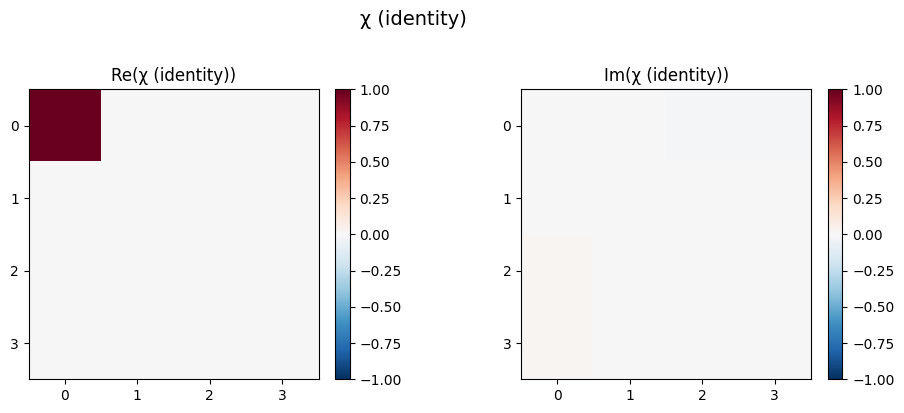

In [7]:
chi_I = np.array([[1,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]])
mean_chi, mean_N, uncertainty_N, mean_F, uncertainty_F, uncertainty_chi = monte_carlo_process(trace_preserving, 'identity_measure.txt', chi_I, 1, num_samples = 100, TP = True, n_jobs=-1)
plot_matrix_heatmap(mean_chi, title='χ (identity)')



We report a total input power $2.275\pm0.003$ mW and a process fidelity of $F = 0.992\pm0.002 \%$. By visual inspection we can also see our process matrix is indeed similar to what we expect.

# Q4b)

Here we present the results for the process tomography of the hadamard gate. We physically implement this by inserting a half-waveplate set to 22.5 degrees into our process stage of our experimental set-up. We expect the following process matrix for the hadamard $$\chi = \begin{pmatrix}0&0&0&0\\0&0.5&0&0.5\\0&0&0&0\\0&0.5&0&0.5\end{pmatrix}$$

Total Power: 2.307640881153611 +- 0.00045695180833857705
Reconstructed Chi Matrix: 
 [[ 0.006+0.j    -0.004+0.003j  0.002+0.005j  0.004+0.011j]
 [-0.004-0.003j  0.55 +0.j     0.003-0.003j  0.48 +0.005j]
 [ 0.002-0.005j  0.003+0.003j  0.005+0.j     0.012-0.j   ]
 [ 0.004-0.011j  0.48 -0.005j  0.012+0.j     0.439+0.j   ]]
Process Fidelity: 0.9742069285079777 +- 0.0003466446990990838


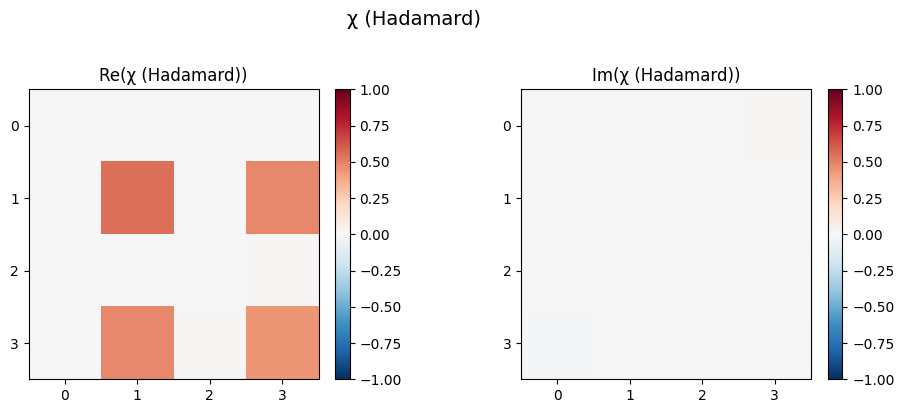

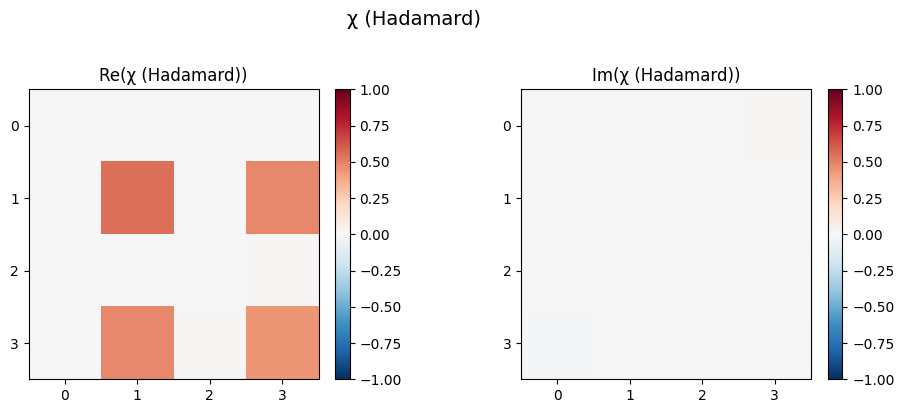

In [565]:
had_chi = np.array([[0,0,0,0],[0,0.5,0,0.5],[0,0,0,0],[0,0.5,0,0.5]])
mean_chi, mean_N, uncertainty_N, mean_F, uncertainty_F, uncertainty_chi = monte_carlo_process(trace_preserving, 'had_measure.txt', had_chi, 1, num_samples = 100)
plot_matrix_heatmap(mean_chi, title='χ (Hadamard)')

We report a total input power of $2.3076\pm0.0004$ mW and a process fidelity of $F = 97.42\pm0.03 \%$. Upon visual expection our process matrix looks like what we would expect. 

# Q4c)

Here we present our results for the process tomography experiment of using the "bad HWP" which essentially means it's retardance is not what it is stated to be. Our goal here is to find the reconstructed value of phi (the retardance) by reconstructing our chi. After finding what our "ideal" process matrix is we can then proceed to monte carlo estimation of our means and error. 

The unitary transformation associated with a waveplate is given by the following matrix product:
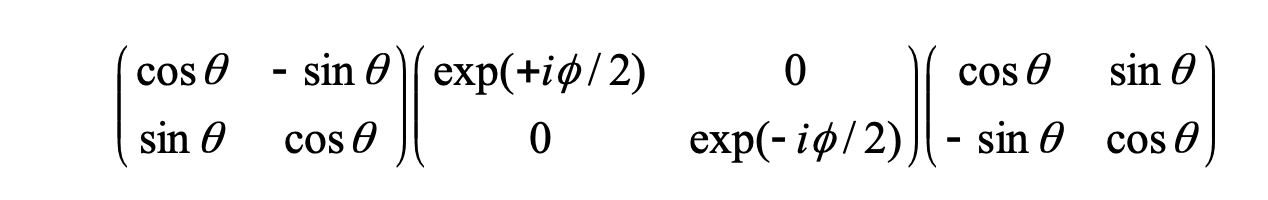

We can decompose this into the pauli basis to the reconsturct what our theoretical chi matrix would be which we do programatically here in our code. We check that our code gives us the right chi if we set it to 22.5 (i.e. the hadamard from the previous question) and confirm it works. 

We do a one shot estimation of chi and then try to find the parameters theta and phi of our waveplate. To find the parameters of the waveplate we minimize the following function $$\mathcal{L} = \sum_{ij}(Re(\chi-\chi_R)^2+Im(\chi-\chi_R)^2$$. 

After this we can proceed to monte-carlo estimation of our mean and uncertainties for our reported values. 


In [566]:
def waveplate(theta, phi):
    '''
    helper function to compute waveplate chi matrix for given theta and phi
    '''
    #compute unitary for waveplate
    A = np.array([[np.cos(theta), np.sin(theta)],[-np.sin(theta), np.cos(theta)]])
    P = np.array([[np.exp(1j*phi/2),0],[0,np.exp(-1j*phi/2)]])
    B = A.T
    U = B@P@A

    def get_pauli_coordinates(U):
        #finds the coefficients of the unitary in the pauli basis, which can be useful for computing the chi matrix
        coeffs = []
        for m in range(len(pauli)):
            coeffs.append(0.5*np.trace(pauli[m]@U))
        return coeffs


    #compute chi matrix for waveplate unitary
    coeffs = get_pauli_coordinates(U)
    chi = np.zeros((4,4), dtype=complex)
    for m in range(len(pauli)):
        for n in range(len(pauli)):
            chi[m,n] = coeffs[m]*np.conj(coeffs[n])
    return chi

#check this works for a half waveplate at 22.5 degrees, which should be equivalent to a hadamard
theta = np.radians(22.5)
phi = np.pi
waveplate_chi = waveplate(theta, phi)
with np.printoptions(3, suppress=True):
    print(f'Waveplate chi matrix: \n {waveplate_chi} \n')


Waveplate chi matrix: 
 [[ 0. +0.j  0. -0.j  0. +0.j  0. -0.j]
 [ 0. +0.j  0.5+0.j -0. +0.j  0.5-0.j]
 [ 0. -0.j -0. -0.j  0. +0.j -0. -0.j]
 [ 0. +0.j  0.5+0.j -0. +0.j  0.5+0.j]] 



In [567]:
def find_waveplate_params(chi):
    '''
    helper function to find the waveplate parameters that best match a given chi matrix, which can be useful for characterizing an unknown waveplate
    '''
    def objective(params):
        theta = params[0]
        phi = params[1]
        chi_est = waveplate(theta, phi)
        return np.sum((np.real(chi-chi_est))**2 + (np.imag(chi-chi_est))**2)
    bounds = [(0, np.pi/2), (0, np.pi)]
    result = opt.basinhopping(objective, x0=[0,0], minimizer_kwargs={ "bounds": bounds})
    theta_opt, phi_opt = result.x
    return theta_opt, phi_opt

In [568]:
chi = MLE_process(trace_preserving, 'bad_HWP_measure.txt', 1, basis = ['H','V','D','R'])
theta_opt, phi_opt = find_waveplate_params(chi)
print(f'Optimal waveplate parameters: theta = {np.degrees(theta_opt):.2f} degrees, phi = {np.degrees(phi_opt):.2f} degrees')

Total Power: 2.363061889215392
Reconstructed Chi Matrix: 
 [[ 0.048+0.j    -0.017-0.006j -0.006-0.004j  0.002-0.179j]
 [-0.017+0.006j  0.036+0.j    -0.002+0.016j  0.085+0.009j]
 [-0.006+0.004j -0.002-0.016j  0.01 +0.j    -0.025-0.002j]
 [ 0.002+0.179j  0.085-0.009j -0.025+0.002j  0.905+0.j   ]]
Optimal waveplate parameters: theta = 2.69 degrees, phi = 157.54 degrees


In [569]:

#find uncertainty in waveplate parameters via monte carlo
def monte_carlo_waveplate_params(chi, num_samples, uncertainty_chi: np.ndarray):
    def run_single_sample(seed):
        np.random.seed(seed)
        noisy_chi = chi + np.random.normal(0, uncertainty_chi, size=chi.shape) #add some noise to chi
        theta, phi = find_waveplate_params(noisy_chi)
        return theta, phi
    
    results = Parallel(n_jobs=-1)(
        delayed(run_single_sample)(i) for i in range(num_samples)
    )
    
    thetas = [r[0] for r in results]
    phis = [r[1] for r in results]

    mean_theta = np.mean(thetas)
    mean_phi = np.mean(phis)
    uncertainty_theta = np.std(thetas)
    uncertainty_phi = np.std(phis)

    print(f'Estimated waveplate parameters: theta = {np.degrees(mean_theta)%180:.2f} degrees +- {np.degrees(uncertainty_theta):.5f} degrees, phi = {np.degrees(mean_phi):.2f} degrees +- {np.degrees(uncertainty_phi):.5f} degrees')
    return mean_theta, uncertainty_theta, mean_phi, uncertainty_phi

Total Power: 2.361883520592326 +- 0.0015271892891325796
Reconstructed Chi Matrix: 
 [[ 0.047+0.j    -0.017-0.007j -0.006-0.004j  0.002-0.179j]
 [-0.017+0.007j  0.036+0.j    -0.002+0.016j  0.085+0.009j]
 [-0.006+0.004j -0.002-0.016j  0.01 +0.j    -0.025-0.002j]
 [ 0.002+0.179j  0.085-0.009j -0.025+0.002j  0.906+0.j   ]]
Process Fidelity: 0.9498239907345367 +- 0.0008724186541586955


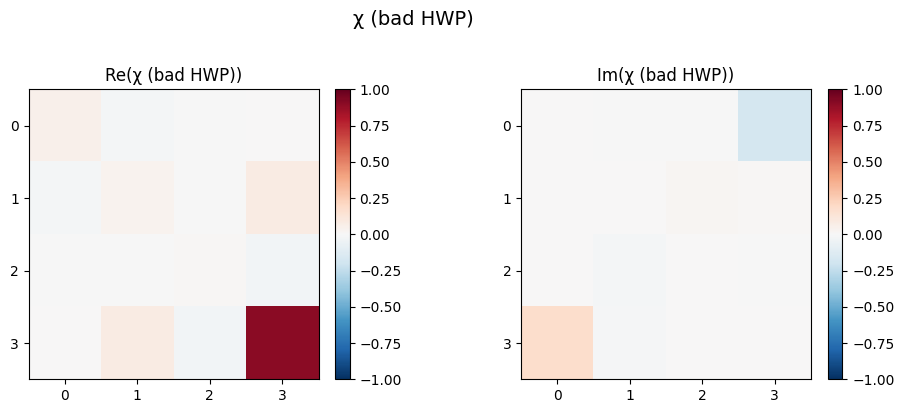

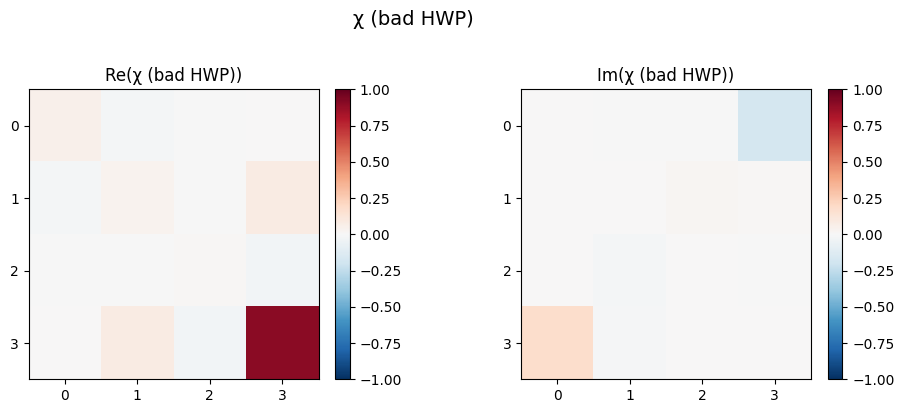

In [570]:
mean_chi, mean_N, uncertainty_N, mean_F, uncertainty_F, uncertainty_chi = monte_carlo_process(trace_preserving, 'bad_HWP_measure.txt', waveplate(theta_opt, phi_opt), 1, num_samples = 10, basis = ['H','V','D','R'], TP = True)
plot_matrix_heatmap(mean_chi, title='χ (bad HWP)')

In [571]:
monte_carlo_waveplate_params(chi, num_samples=100, uncertainty_chi=uncertainty_chi)

Estimated waveplate parameters: theta = 2.69 degrees +- 0.00483 degrees, phi = 157.54 degrees +- 0.02050 degrees


(np.float64(0.04688966438751639),
 np.float64(8.43148757520451e-05),
 np.float64(2.749611208397853),
 np.float64(0.00035783654389852213))

In the end, we get a reconstructed input power of $2.236\pm0.002$ mW, waveplate parameters $\theta = 2.69\pm0.004\degree$ and $\phi = 157.55\pm0.02\degree$ meaning that the bad waveplate is thinner than it should be with a retardance of ~$0.875\pi$. Our prcess fidelity we get is $F=94.98\pm0.09\%$

# Q5

Here we perform process tomography for a non-unitary channel. We use the calcite beam displacer in our processing stage which will spatially couple polarization to the spatial path of the light similarly to what we did in experiment #3. We use the process fidelity formula for non-unitary channels which is given by $F = Tr(\sqrt{\sqrt{\chi}\chi_{ideal}\sqrt{\chi}})^2$ where $\chi_{ideal}$ is the ideal process matrix for the calcite beam displacer channel.

# Q5a)

Total Power: 2.3043326552587526 +- 0.1596046283049988
Reconstructed Chi Matrix: 
 [[ 0.497+0.j     0.   -0.002j  0.002-0.001j  0.006+0.002j]
 [ 0.   +0.002j  0.004+0.j    -0.001+0.j     0.04 +0.002j]
 [ 0.002+0.001j -0.001-0.j     0.001+0.j    -0.013-0.j   ]
 [ 0.006-0.002j  0.04 -0.002j -0.013+0.j     0.497+0.j   ]]
Process Fidelity: 0.9943618935283892 +- 0.0007593596354618249


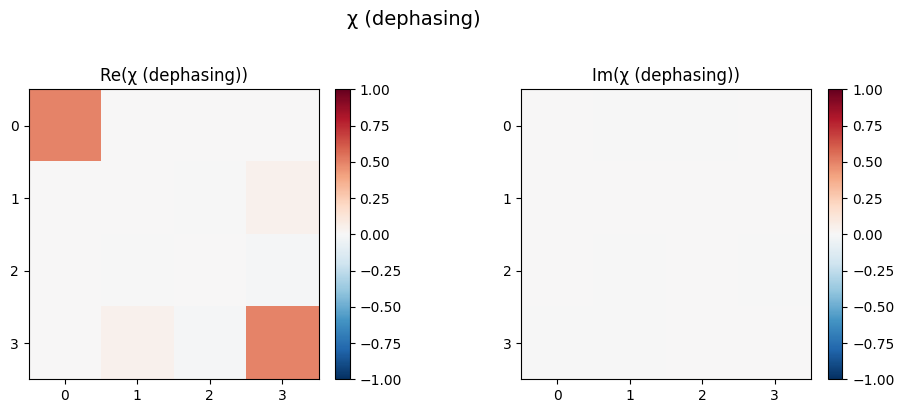

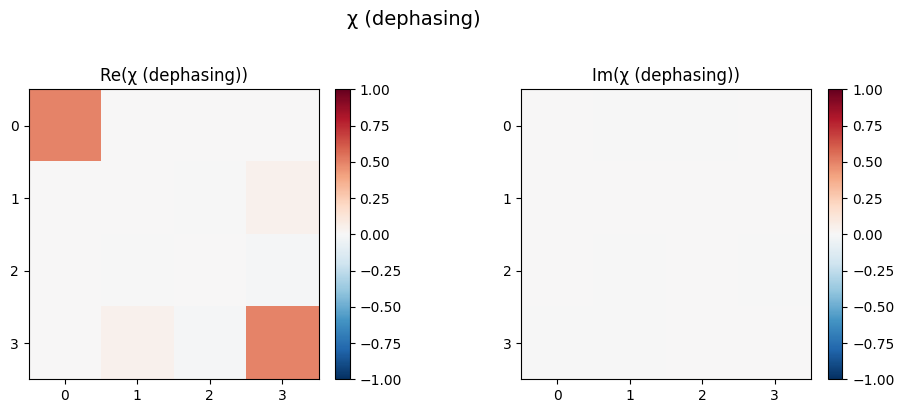

In [572]:
dephasing_chi = np.array([[0.5,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0.5]])
mean_chi, mean_N, uncertainty_N, mean_F, uncertainty_F, uncertainty_chi = monte_carlo_process(trace_preserving, 'disp_measure.txt', dephasing_chi, 1, num_samples = 100)
plot_matrix_heatmap(mean_chi, title='χ (dephasing)')

We report a total input power of $2.3 \pm 0.15$ mW, a process fidelity of $F = 99.43\pm0.07\%$ which is consistent with what we expect for a maximally dephasing channel (i.e. p=0.5). I suppose in if we wanted to be even more rigorous we could actually characterize what p is specifically (since in practice there might be beam displacer errors that affect this parameter) but our fidelity suggests that 0.5 is a good value for p. 

# Q5b)
We measure both paths with our power meter and by doing so we trace over the spatial degree of freedom which gives us a mixed state (effectively projects our input state onto the z axis of the bloch sphere). The channel we are implementing here is a dephasing channel/phase damping, which maps points on the bloch sphere to the z axis on the bloch sphere. This has the krauss form $\rho' = (1-p)*\rho + (p)Z\rho Z$ with our krauss operators being $\{\sqrt{1-p}I,\sqrt{p}Z\}$, which gives the chi matrix $$\chi = \begin{pmatrix}1-p&0&0&0\\0&0&0&0\\0&0&0&0\\0&0&0&p\end{pmatrix}$$. 

Because the beam-displacer couples polarization to spatial path, we lose all coherence in our state (we know chich path it took if we measure H/V and we know which polarization we have if we measure which path the photon took). By measuring both paths we take a partial trace over the spatial degree of freedom of an entangled state which theoretically gives us a mixed state. So we end up with a totally dephasing channel so p=0.5 and we expect the following chi matrix $$\chi = \begin{pmatrix}0.5&0&0&0\\0&0&0&0\\0&0&0&0\\0&0&0&0.5\end{pmatrix}$$

# Q6

Here we perform process tomography on a non-trace preserving channel. We implement this by using a partial polarizer in our process stage which we create by tilting a microscope slide pair (in theory to the brewster angle). The partial polarizer works because the glass interface will transmit different ammounts of light depending on whether it is planar polarized or transversly polarized to the plane of reflection. By tunning the angle of the interface we can tune how much p-polarized light is transmitted, which at the brewster angle all the p-polarized light should be transmitted. 

In our experiment, V is the better-transmitted polarization ($P_{V \ V} > P_{HH}$) since it is in the reflection plane, so the Kraus operator is $$K = \begin{pmatrix}\sqrt{1-a}&0\\0&1\end{pmatrix}$$ where $a$ is the polarizing power. When $a=0$ the channel is the identity (no polarization effect), and when $a=1$ the channel is a perfect polarizer. The polarizing power can be measured directly from H and V transmission measurements as $a = 1 - P_{\min}/P_{\max}$.

Decomposing into the Pauli basis with coefficients $c_0 = (1+\sqrt{1-a})/2$ and $c_3 = (\sqrt{1-a}-1)/2$, this gives the chi matrix $$\chi = \begin{pmatrix}\frac{(1+\sqrt{1-a})^2}{4}&0&0&\frac{-a}{4}\\0&0&0&0\\0&0&0&0\\\frac{-a}{4}&0&0&\frac{(1-\sqrt{1-a})^2}{4}\end{pmatrix}$$

We use the following formula for the process fidelity for non-trace preserving channels $$F = \frac{Tr(\sqrt{\sqrt{\chi}\chi_{ideal}\sqrt{\chi}})^2}{Tr(\chi)Tr(\chi_{ideal})}$$ where $\chi_{ideal}$ is the ideal process matrix for the partial polarizer channel.

In [573]:
def non_trace_preserving(t, data, l, basis = ['H','V','D','R']):
    measurements = data[2]
    uncertainties = data[3]
    chi = chi_choleski_unconstrained(t)
    loss = 0
    #main loss term
    for i in range(len(basis)):
        for j in range(len(basis)):
            loss += (measurements[i,j]-t[16]*pauli_sum(chi, i,j,basis))**2/(uncertainties[i,j]+1e-6)

    def reg_sum_non_trace(chi, k, t):

        U = (t[18]+1j*t[19])*np.eye(2)+(t[20]+1j*t[21])*X+(t[22]+1j*t[23])*Y+(t[24]+1j*t[25])*Z
        chi_term = 0
        for n in range(len(pauli)):
            for m in range(len(pauli)):
                chi_term += chi[m,n]*np.trace(pauli[k]@pauli[n]@pauli[m])
        u_term = np.trace(pauli[k]@U@np.array([[1,0],[0,t[17]]])@U.conj().T)
        return chi_term - u_term

    #regularizer
    reg = 0
    for k in range(len(pauli)):
        reg += np.abs(reg_sum_non_trace(chi, k, t))**2

    #regularizer to encourage the parameters for U to have norm2=1, using complex conjugate to compute norm of complex parameters
    reg2 = (t[18]**2+t[19]**2+t[20]**2+t[21]**2+t[22]**2+t[23]**2+t[24]**2+t[25]**2-1)**2

    return np.real(loss+l*reg+reg2)

def partial_polarizer(a):
    '''
    chi matrix for a partial polarizer with polarizing power a.
    Kraus operator K = diag(sqrt(1-a), 1) where 0 <= a <= 1.
    a=0: identity (no polarization), a=1: perfect polarizer.
    V is the fully transmitted polarization (matches our data: P_VV > P_HH).
    '''
    s = np.sqrt(1-a)
    chi = np.zeros((4,4), dtype=complex)
    chi[0,0] = ((1+s)/2)**2
    chi[0,3] = -a/4
    chi[3,0] = -a/4
    chi[3,3] = ((1-s)/2)**2
    return chi

chi = MLE_process(non_trace_preserving, 'nonTP_measure.txt', 10000, basis = ['H','V','D','R'], TP = False)

Total Power: 1.2072318765506078
Reconstructed Chi Matrix: 
 [[ 1.369+0.j     0.005+0.008j -0.001-0.008j -0.042-0.032j]
 [ 0.005-0.008j  0.001+0.j     0.001+0.001j -0.001-0.001j]
 [-0.001+0.008j  0.001-0.001j  0.002+0.j    -0.002-0.002j]
 [-0.042+0.032j -0.001+0.001j -0.002+0.002j  0.005+0.j   ]]


In [574]:
def get_partial_polarizer_params(chi):
    '''
    Find the partial polarizer strength a that best matches a given chi matrix,
    using a normalized comparison to avoid scale ambiguity in non-TP reconstructions.
    '''
    chi_norm = chi / (np.trace(chi) + 1e-12)

    def objective(params):
        a = params[0]
        chi_est = partial_polarizer(a)
        chi_est_norm = chi_est / (np.trace(chi_est) + 1e-12)
        return np.sum((np.real(chi_norm-chi_est_norm))**2 + (np.imag(chi_norm-chi_est_norm))**2)

    bounds = [(0, 1)]
    result = opt.basinhopping(objective, x0=[0.5], minimizer_kwargs={"bounds": bounds})
    a_opt = result.x[0]
    return a_opt


def monte_carlo_partial_polarizer_params(chi, num_samples, uncertainty_chi):
    def run_single_sample(seed):
        np.random.seed(seed)
        noisy_chi = chi + np.random.normal(0, uncertainty_chi, size=chi.shape)
        a_opt = get_partial_polarizer_params(noisy_chi)
        return a_opt

    results = Parallel(n_jobs=-1)(
        delayed(run_single_sample)(i) for i in range(num_samples)
    )

    mean_a = np.mean(results)
    uncertainty_a = np.std(results)
    return mean_a, uncertainty_a

In [575]:
# Part (a): direct measurement of polarizing power
data = read_process('nonTP_measure.txt')
measurements = data[2]
P_HH = measurements[0,0]  # H→H power
P_VV = measurements[1,1]  # V→V power
a_direct = 1 - min(P_HH, P_VV)/max(P_HH, P_VV)
print(f'Direct measurement: P_HH = {P_HH:.3f} mW, P_VV = {P_VV:.3f} mW')
print(f'Partial polarizer polarizing power (direct): a = {a_direct:.4f}')

# Part (b): get polarizing power from reconstructed chi
a_opt = get_partial_polarizer_params(chi)
print(f'Estimated partial polarizer polarizing power from chi: a = {a_opt:.4f}')

Direct measurement: P_HH = 1.574 mW, P_VV = 1.756 mW
Partial polarizer polarizing power (direct): a = 0.1036
Estimated partial polarizer polarizing power from chi: a = 0.1158


Total Power: 1.1429679451754204 +- 0.3456348839172947
Reconstructed Chi Matrix: 
 [[ 1.599+0.j     0.006+0.009j -0.001-0.009j -0.049-0.034j]
 [ 0.006-0.009j  0.003+0.j     0.002+0.j    -0.001-0.002j]
 [-0.001+0.009j  0.002-0.j     0.004+0.j    -0.001-0.002j]
 [-0.049+0.034j -0.001+0.002j -0.001+0.002j  0.007+0.j   ]]
Process Fidelity: 0.9932164531846854 +- 0.003538178038896397


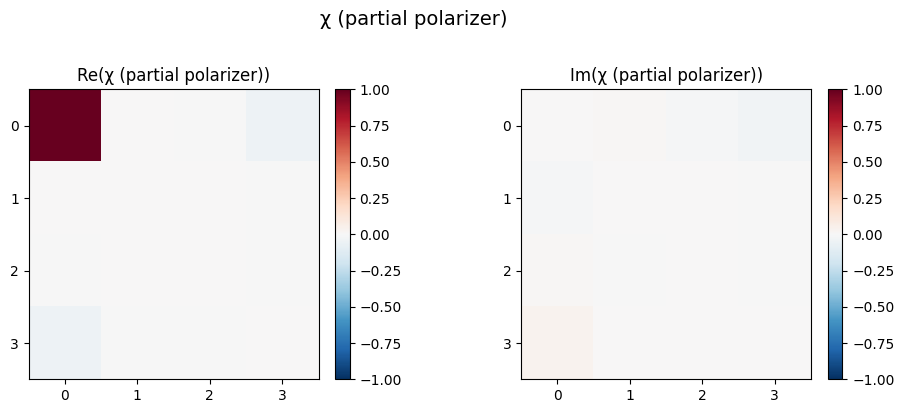

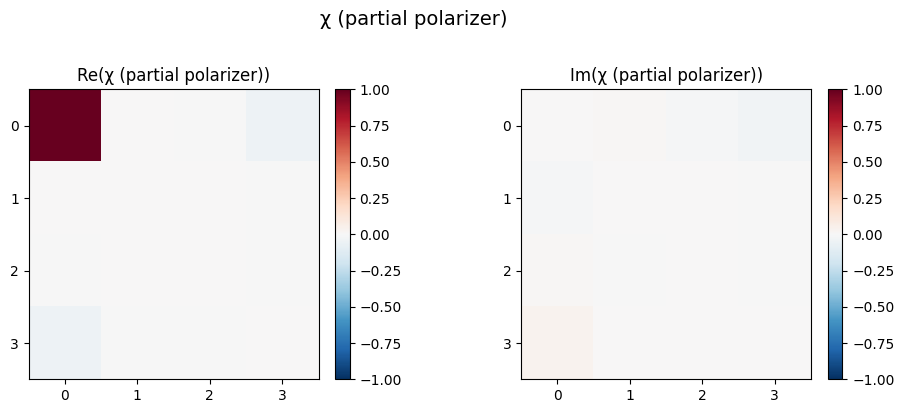

In [576]:
#monte carlo process
mean_chi, mean_N, uncertainty_N, mean_F, uncertainty_F, uncertainty_chi = monte_carlo_process(non_trace_preserving, 'nonTP_measure.txt', partial_polarizer(a_opt), 10000, num_samples = 100, basis = ['H','V','D','R'], TP = False)
plot_matrix_heatmap(mean_chi, title='χ (partial polarizer)')

In [577]:
mean_a, uncertainty_a = monte_carlo_partial_polarizer_params(chi, num_samples=100, uncertainty_chi=uncertainty_chi)
print(f'Estimated partial polarizer strength: a = {mean_a:.4f} ± {uncertainty_a:.4f}')

Estimated partial polarizer strength: a = 0.1404 ± 0.0932


here we report a total input power of $1.1 \pm 0.3$ mW, a process fidelity of $F = 99.3\pm0.3\%$. We also report a value for a = $0.14\pm 0.09$ which seems wrong. We can see from our process matrix that we essentially have an identity channel with very faint terms in the corner. Our result is somewhat consistent with the value for a if we calculate it using the formula $a = 1 - P_{\min}/P_{\max}$ where we take $P_{\min}$ to be our H measurement and $P_{\max}$ to be our V measurement, which gives us a value of $a = 0.101$ if we account for waveplate setting errors. I'm assuming we did something wrong in our procedure which caused an issue. Our process fidelity is also very high so I have to assume the code is correct at this points (I really tried my best to debug and make sure everything was working correctly) for the data that we have and that the issue was how we performed the experiment. 